## step 1 - imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../datasets/train.csv")

In [2]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## step 2 - exploring the data

In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## step 3 - separate column by type
- categorical
- numerical

In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object','str']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)
print()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Numerical columns (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',

## step 4 - target variable analysis

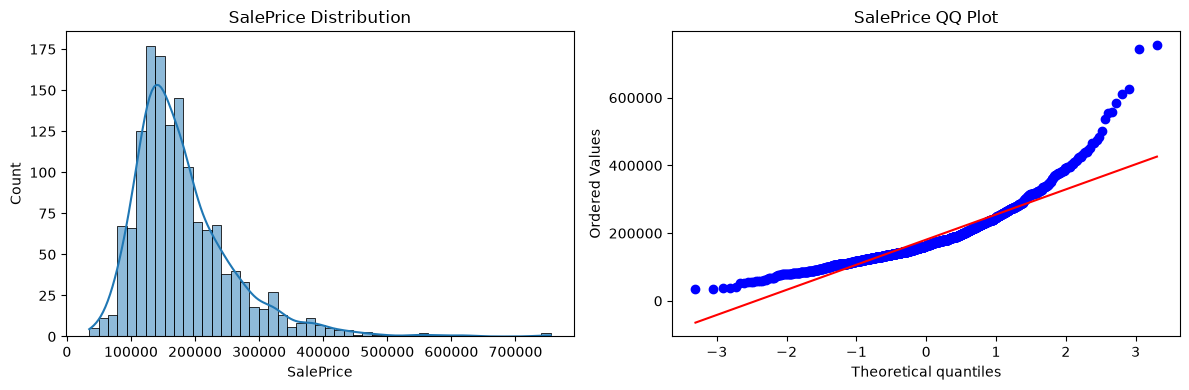

Skewness: 1.88
Kurtosis: 6.54


In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], kde=True)
plt.title('SalePrice Distribution')

plt.subplot(1,2,2)
from scipy import stats
stats.probplot(df['SalePrice'], dist='norm', plot=plt)
plt.title('SalePrice QQ Plot')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['SalePrice'].skew():.2f}")
print(f"Kurtosis: {df['SalePrice'].kurt():.2f}")

### from the graph we can see that
 **distribution plot** is **clearly right skewed** - most houses are between 100k-200k, long tail toward 700k

**QQ Plot**
- Points curve away from the diagonal line significantly at both ends
- Confirms non-normal distribution

**Skewness** = **1.88*** - **highly skewdd**(anything above 1 need transformation)
**Kurtosis** = **6.54** — **very heavy tails**, extreme values more common than normal
    

### fixing the problem by appling log transfrom

In [8]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])


In [9]:
df[['SalePrice','SalePrice_log']]

,SalePrice,SalePrice_log
0,208500,12.247699
1,181500,12.109016
2,223500,12.317171
3,140000,11.849405
4,250000,12.429220
...,...,...
1455,175000,12.072547
1456,210000,12.254868
1457,266500,12.493133
1458,142125,11.864469


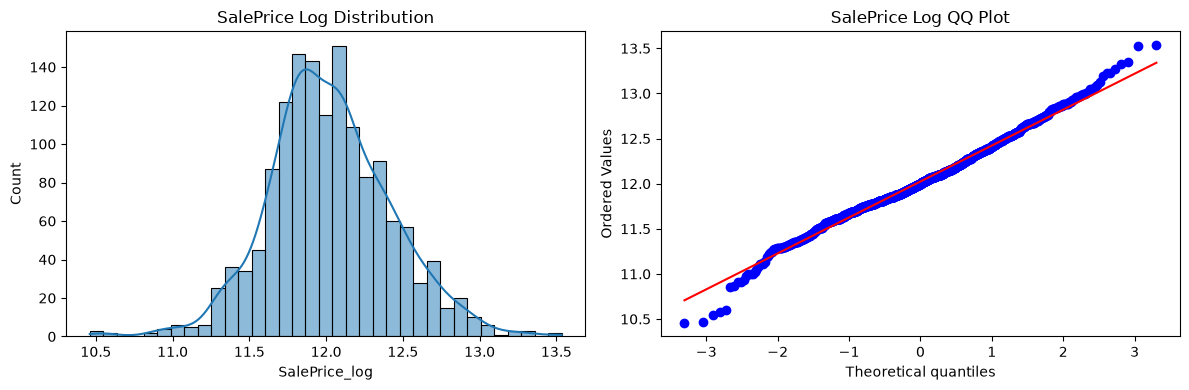

Skewness after log: 0.12
Kurtosis after log: 0.81


In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice_log'], kde=True)
plt.title('SalePrice Log Distribution')

plt.subplot(1,2,2)
from scipy import stats
stats.probplot(df['SalePrice_log'], dist='norm', plot=plt)
plt.title('SalePrice Log QQ Plot')

plt.tight_layout()
plt.show()

print(f"Skewness after log: {df['SalePrice_log'].skew():.2f}")
print(f"Kurtosis after log: {df['SalePrice_log'].kurt():.2f}")

we can see that log transform has transform the column perfectly making it almost normally distributed with just a few deviations

### step 5 - EDA on numerical features

In [11]:
corr = df[numerical_cols].corr()['SalePrice'].sort_values(ascending = False)
print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

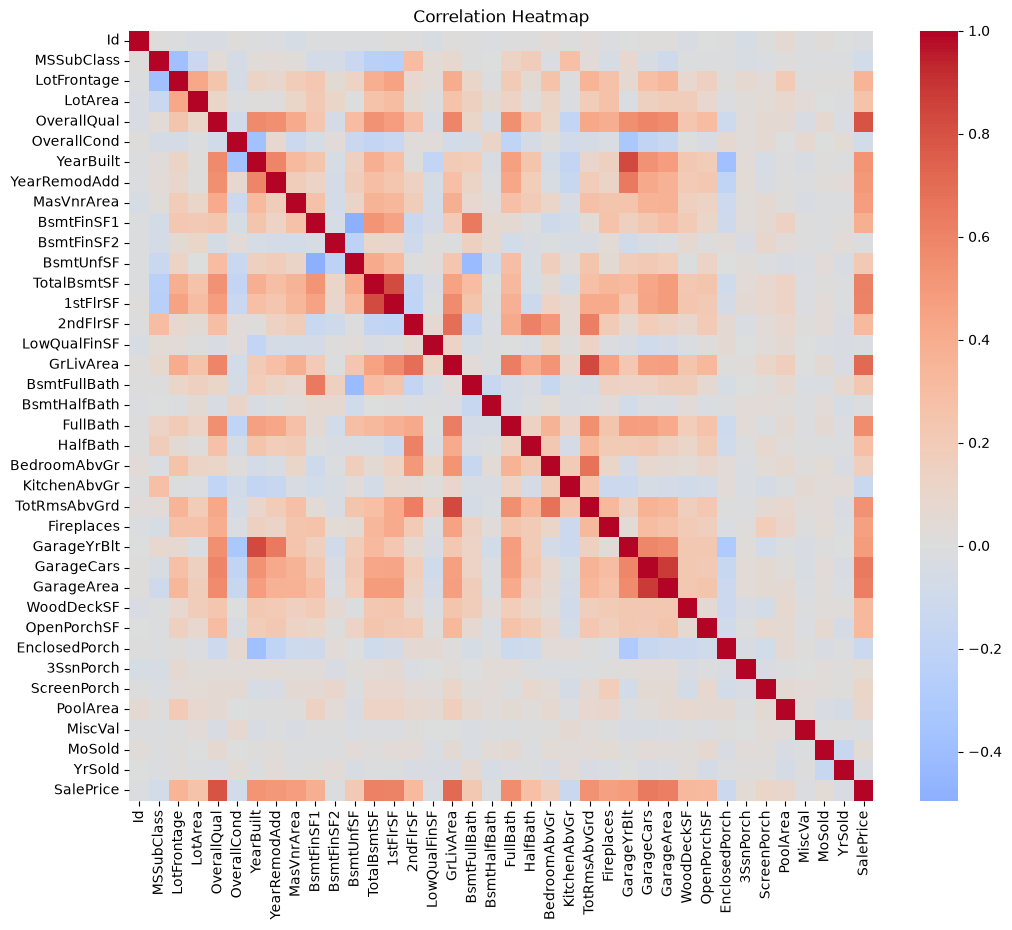

In [12]:
# plotting a heat map
plt.figure(figsize=(12,10))
top_corr = df[numerical_cols].corr()
sns.heatmap(top_corr, cmap = 'coolwarm', center = 0, annot = False)
plt.title('Correlation Heatmap')
plt.show()

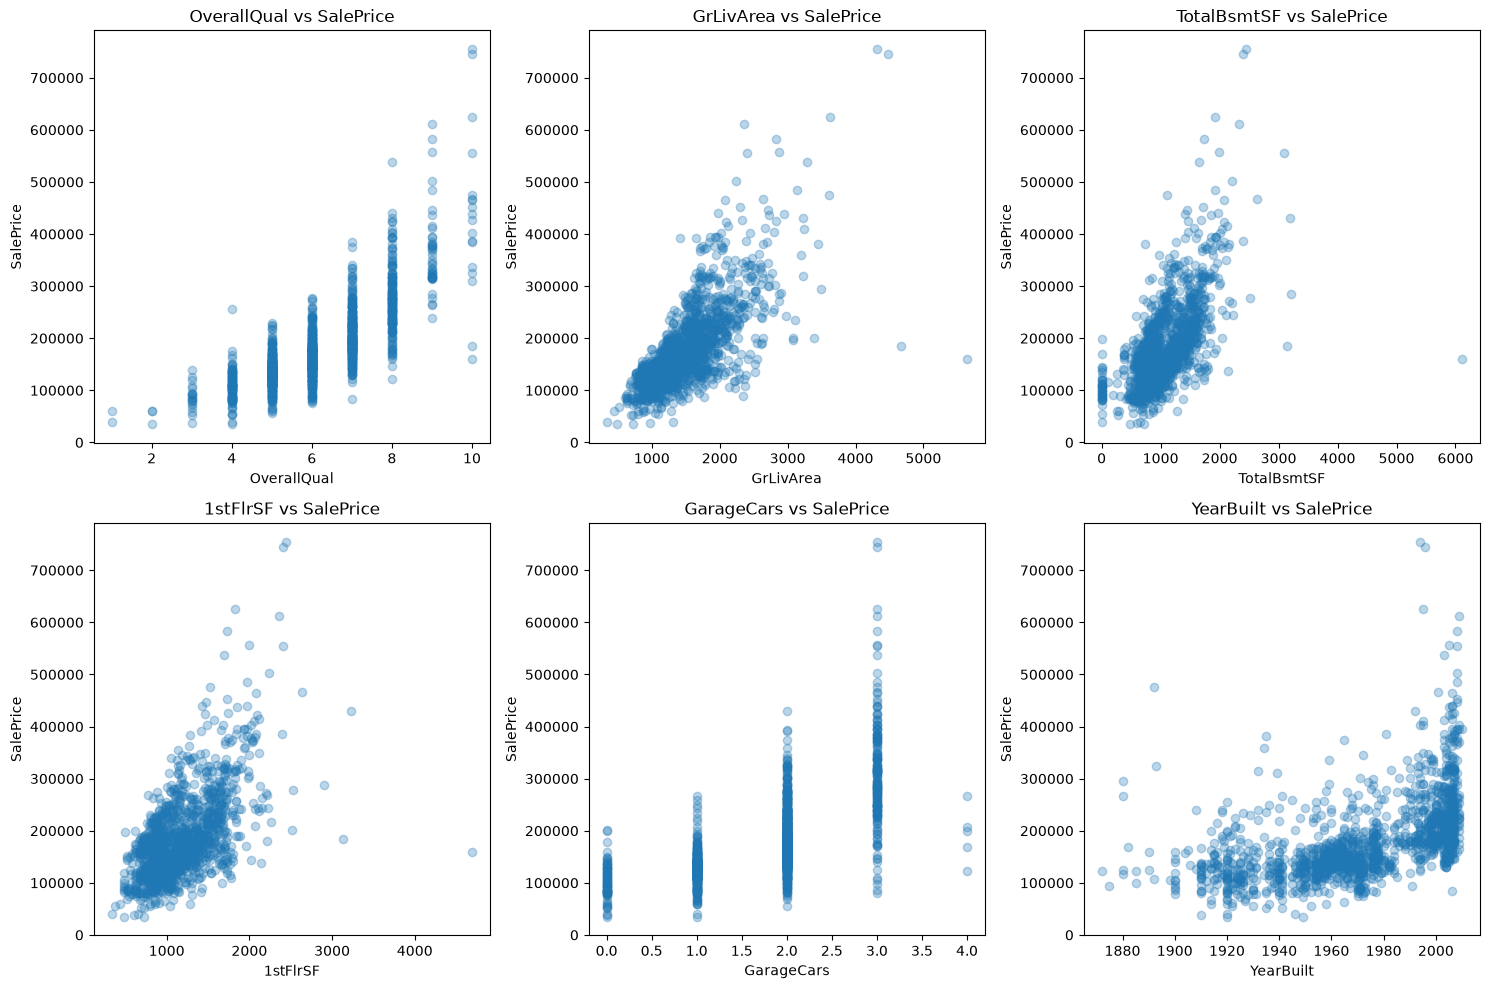

In [13]:
top_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 
                '1stFlrSF', 'GarageCars', 'YearBuilt']

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    plt.scatter(df[col], df['SalePrice'], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()

### step 7 - EDA on categorical features

In [14]:
# Check how much SalePrice varies across each categorical feature
cat_importance = {}

for col in categorical_cols:
    groups = df.groupby(col)['SalePrice'].median()
    # range of median prices across categories = how much this feature matters
    cat_importance[col] = groups.max() - groups.min()

cat_importance = pd.Series(cat_importance).sort_values(ascending=False)
print(cat_importance)

PoolQC           319000.0
ExterQual        282356.5
Condition2       228250.0
Neighborhood     227000.0
Exterior2nd      214000.0
BsmtQual         206000.0
KitchenQual      201750.0
RoofMatl         195500.0
Exterior1st      191000.0
FireplaceQu      182750.0
MiscFeature      156000.0
SaleType         153550.0
SaleCondition    140600.0
MSZoning         131250.0
BsmtCond         129879.0
GarageType       119500.0
GarageQual       112615.0
MasVnrType       107839.0
HeatingQC        107700.0
Electrical       103000.0
Foundation       100850.0
Condition1        94450.0
Heating           92000.0
ExterCond         90870.0
RoofStyle         86000.0
LandContour       82850.0
HouseStyle        82750.0
Functional        80500.0
GarageFinish      80000.0
LotShape          75000.0
BsmtFinType1      74750.0
BsmtExposure      72975.0
CentralAir        70000.0
GarageCond        62000.0
BsmtFinType2      60125.0
PavedDrive        57500.0
Alley             53000.0
Street            48750.0
BldgType    

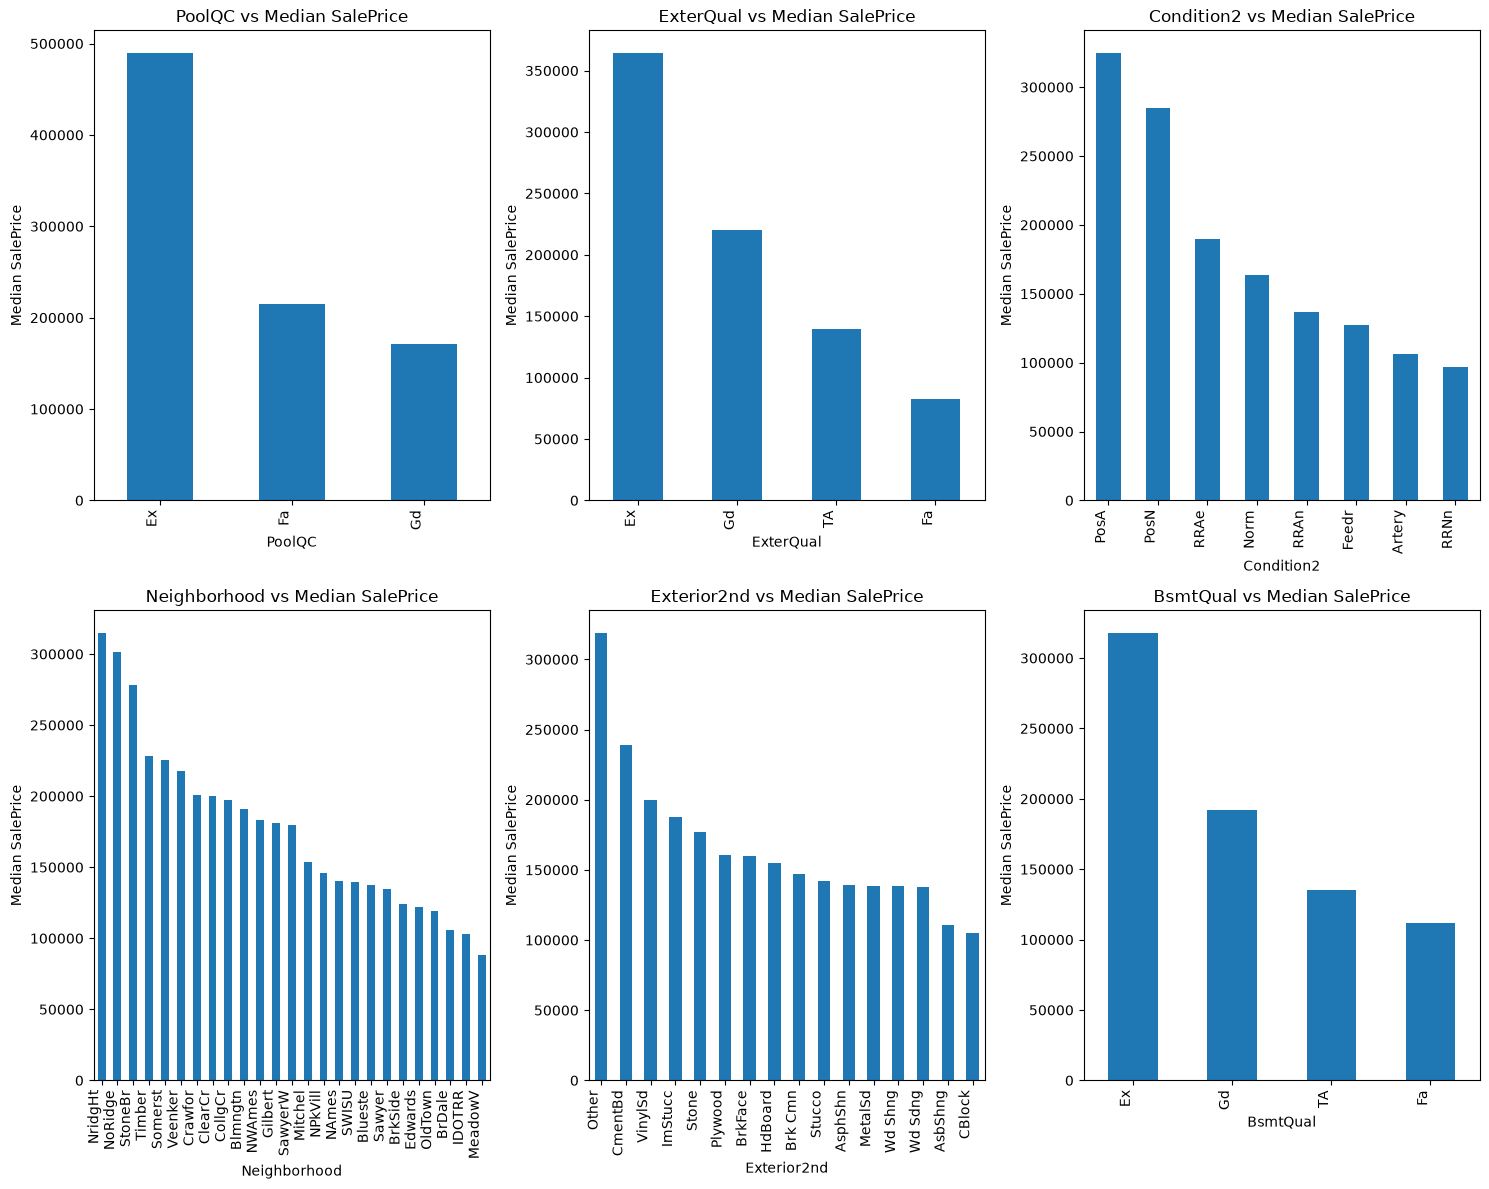

In [15]:
top_cat = cat_importance.head(6).index.tolist()

plt.figure(figsize=(15,12))
for i, col in enumerate(top_cat):
    plt.subplot(2, 3, i+1)
    df.groupby(col)['SalePrice'].median().sort_values(ascending=False).plot(kind='bar')
    plt.title(f'{col} vs Median SalePrice')
    plt.xticks(rotation=90, ha='right')
    plt.ylabel('Median SalePrice')

plt.tight_layout()
plt.show()

### step 7 - missing value Analysis

In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing, 
    'Missing %': missing_pct.round(2)
})
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtExposure             38       2.60
BsmtFinType2             38       2.60
BsmtQual                 37       2.53
BsmtCond                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


In [17]:
# filling the missing values

# Group 1 - fill with "None"
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

# Group 2 - Numerical
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Group 3 — most frequent
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Verify
print(df.isnull().sum().sum()) 


0


### Handling outliers

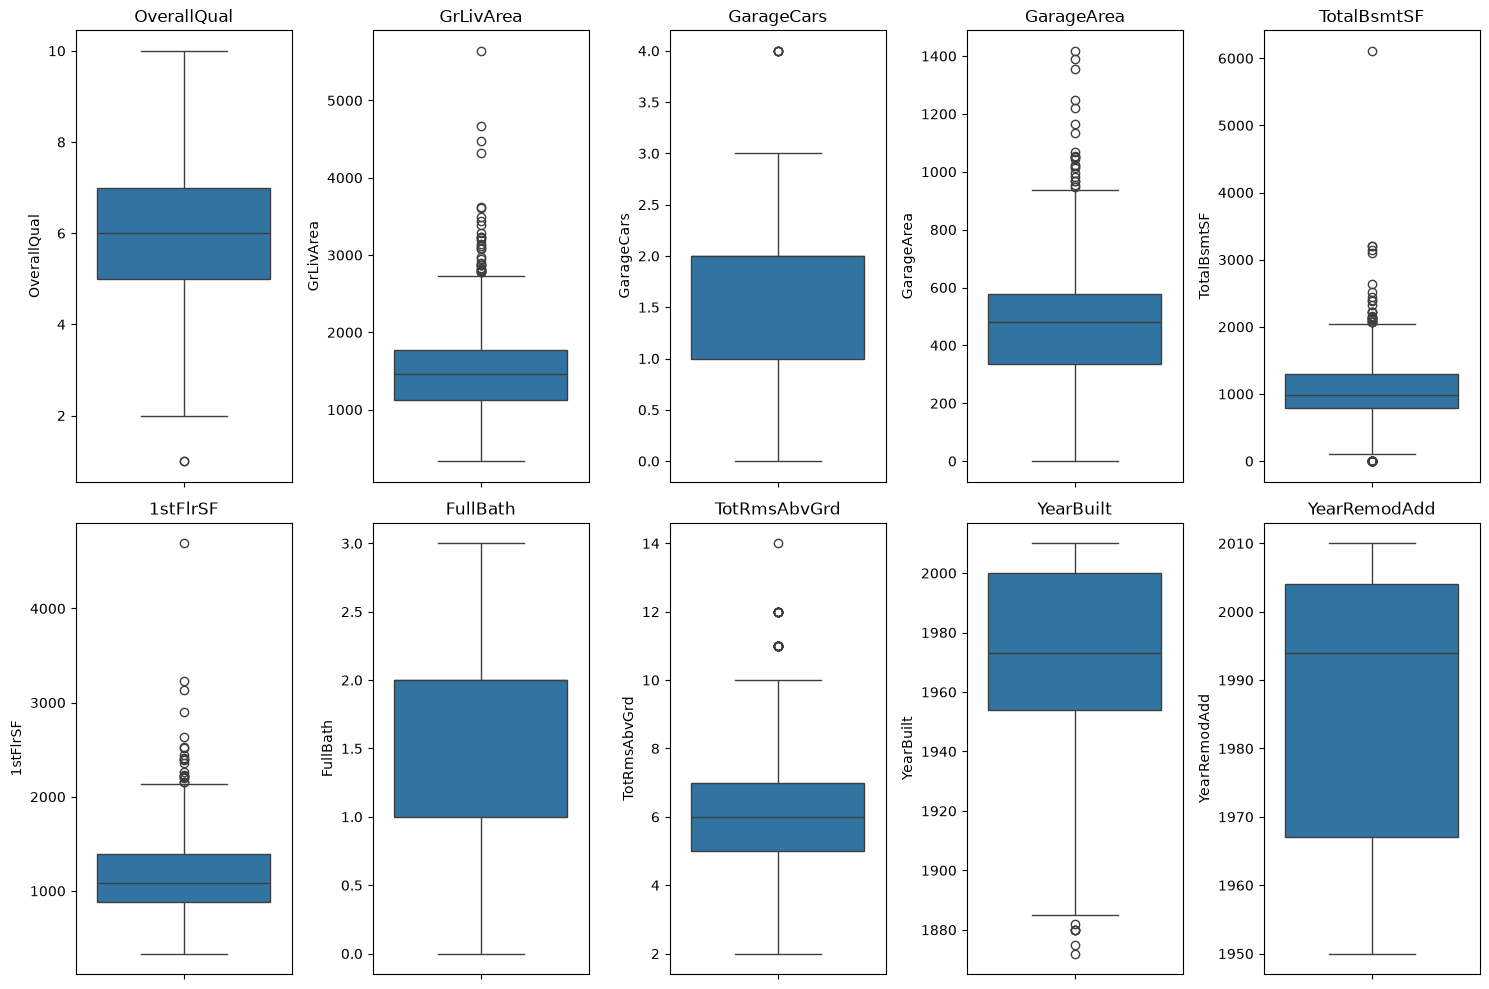

In [18]:

# use top correlated numerical features automatically
top_num = corr.drop('SalePrice').head(10).index.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_num):
    plt.subplot(2, 5, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower,upper)
    return df

# apply to columns with outliers
outlier_cols = ['GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'LotArea']
for col in outlier_cols:
    df = cap_outliers(df, col)

print('Outliers capped successfully')

Outliers capped successfully


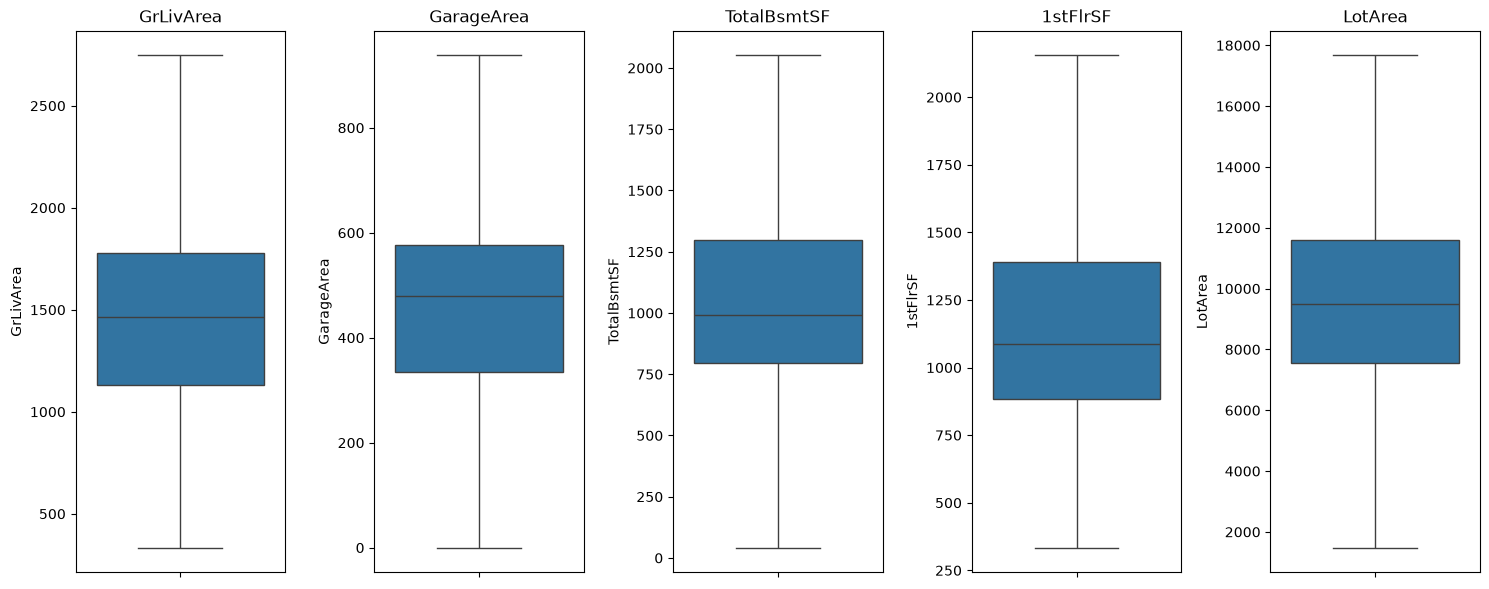

In [20]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(outlier_cols):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### step 9 - creating new features


In [21]:
# 1. Total area of the house
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. House age at time of sale
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# 3. Was the house remodeled?
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# 4. Total bathrooms
df['TotalBath'] = (df['FullBath'] + df['BsmtFullBath'] + 
                   0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath'])

# 5. Has pool, garage, fireplace, basement
df['HasPool']      = (df['PoolArea'] > 0).astype(int)
df['HasGarage']    = (df['GarageArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasBasement']  = (df['TotalBsmtSF'] > 0).astype(int)

# verify
print('New features created:')
df[['TotalSF','HouseAge','IsRemodeled','TotalBath',
          'HasPool','HasGarage','HasFireplace','HasBasement']]

New features created:


,TotalSF,HouseAge,IsRemodeled,TotalBath,HasPool,HasGarage,HasFireplace,HasBasement
0,2566.0,5,0,3.5,0,1,0,1
1,2524.0,31,0,2.5,0,1,1,1
2,2706.0,7,1,3.5,0,1,1,1
3,2473.0,91,1,2.0,0,1,1,1
4,3343.0,8,0,3.5,0,1,1,1
...,...,...,...,...,...,...,...,...
1455,2600.0,8,1,2.5,0,1,1,1
1456,3615.0,32,1,3.0,0,1,1,1
1457,3492.0,69,1,2.0,0,1,1,1
1458,2156.0,60,1,2.0,0,1,0,1


In [22]:
new_features = ['TotalSF', 'HouseAge', 'IsRemodeled', 'TotalBath',
                'HasPool', 'HasGarage', 'HasFireplace', 'HasBasement']

new_corr = df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print(new_corr)

TotalSF         0.817888
TotalBath       0.631731
HasFireplace    0.471908
HasGarage       0.236832
HasPool         0.093708
IsRemodeled    -0.021933
HouseAge       -0.523350
HasBasement          NaN
Name: SalePrice, dtype: float64


In [23]:
# fix HasBasement using original logic
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
print(df['HasBasement'].value_counts())

# drop IsRemodeled — no signal
df = df.drop(columns=['IsRemodeled'])

HasBasement
1    1460
Name: count, dtype: int64


In [24]:
df = df.drop(columns=['HasBasement'])
print('HasBasement dropped')

HasBasement dropped


In [25]:
# drop columns with no predictive value
df = df.drop(columns=['Id',          # just row number
                       'MoSold',      # month sold — very low correlation
                       'YrSold',      # year sold — very low correlation
                       '3SsnPorch',   # very low correlation
                       'BsmtFinSF2',  # very low correlation
                       'LowQualFinSF',# very low correlation
                       'MiscVal'])    # very low correlation

print(f'Remaining columns: {df.shape[1]}')

Remaining columns: 81


In [26]:
print(df.columns.tolist())
print(df.shape)

['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondit

In [29]:
cols_to_exclude = ['SalePrice', 'SalePrice_log']

numerical_cols = df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in cols_to_exclude]

categorical_cols = df.select_dtypes(include = ['object', 'str']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 36
Categorical columns: 43


In [30]:
# ordinal columns — have a natural order
ordinal_cols = {
    'ExterQual':  ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond':  ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual':   ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond':   ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtExposure':['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1':['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2':['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'HeatingQC':  ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual':['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'FireplaceQu':['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageFinish':['None', 'Unf', 'RFn', 'Fin'],
    'GarageQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'PoolQC':     ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence':      ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
}

# everything else → OneHotEncoder
ohe_cols = [col for col in categorical_cols if col not in ordinal_cols.keys()]

print(f'Ordinal columns: {len(ordinal_cols)}')
print(f'OHE columns: {len(ohe_cols)}')
print(f'\nOHE columns list:')
print(ohe_cols)

Ordinal columns: 15
OHE columns: 28

OHE columns list:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition']


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# prepare ordinal categories in correct order
ordinal_categories = [ordinal_cols[col] for col in ordinal_cols.keys()]

# split features and target
X = df.drop(columns=['SalePrice', 'SalePrice_log'])
y = df['SalePrice_log']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape} ")

X_train shape: (1168, 79)
X_test shape: (292, 79) 


In [34]:
preprocessor = ColumnTransformer([
    ('ordinal',
     OrdinalEncoder(categories = ordinal_categories, handle_unknown = 'use_encoded_value',unknown_value = -1),list(ordinal_cols.keys())),

    ('ohe', OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore'), ohe_cols)
                                 ], remainder = 'passthrough')

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(f'X_train shape after encoding: {X_train_encoded.shape}')
print(f'X_test shape after encoding:  {X_test_encoded.shape}')

X_train shape after encoding: (1168, 209)
X_test shape after encoding:  (292, 209)


C:\Users\NEVIL\applied-feature-engineering\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [14, 21] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [35]:
# get numerical column indices in encoded array
# easier to work with original X_train for skewness check
skewness = X_train[numerical_cols].skew().sort_values(ascending=False)
print(skewness)

PoolArea         14.396098
HasPool          13.862369
KitchenAbvGr      4.445055
ScreenPorch       4.090393
BsmtHalfBath      4.005786
EnclosedPorch     3.163946
LotFrontage       2.484232
OpenPorchSF       2.331890
MasVnrArea        2.294117
BsmtFinSF1        1.862132
WoodDeckSF        1.587330
MSSubClass        1.438804
BsmtUnfSF         0.910628
2ndFlrSF          0.801209
OverallCond       0.733180
TotRmsAbvGrd      0.687336
HalfBath          0.651296
Fireplaces        0.637526
HouseAge          0.620361
TotalSF           0.616445
BsmtFullBath      0.612032
1stFlrSF          0.611389
GrLivArea         0.579674
TotalBath         0.315672
BedroomAbvGr      0.289882
TotalBsmtSF       0.234787
OverallQual       0.196575
LotArea           0.193429
FullBath          0.038169
GarageArea       -0.111529
HasFireplace     -0.127131
GarageCars       -0.389732
YearRemodAdd     -0.508067
YearBuilt        -0.623404
GarageYrBlt      -3.898950
HasGarage        -3.917573
dtype: float64


In [37]:
binary_cols = ['HasPool', 'HasGarage', 'HasFirePlace']
skewed_cols = skewness[(abs(skewness) > 0.75)].index.tolist()
skewed_cols = [col for col in skewed_cols if col not in binary_cols]

print(f"Column to transform ({len(skewed_cols)}):")
print(skewed_cols)

# apply log1p to skewed columns
for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# verify skewness improved
print('\nSkewness after transformation')
print(X_train[skewed_cols].skew().sort_values(ascending = False))

Column to transform (14):
['PoolArea', 'KitchenAbvGr', 'ScreenPorch', 'BsmtHalfBath', 'EnclosedPorch', 'LotFrontage', 'OpenPorchSF', 'MasVnrArea', 'BsmtFinSF1', 'WoodDeckSF', 'MSSubClass', 'BsmtUnfSF', '2ndFlrSF', 'GarageYrBlt']

Skewness after transformation
PoolArea         13.874124
BsmtHalfBath      3.893541
KitchenAbvGr      3.722592
ScreenPorch       3.062578
EnclosedPorch     2.179302
MasVnrArea        0.452588
2ndFlrSF          0.268476
MSSubClass        0.255827
WoodDeckSF        0.181798
OpenPorchSF      -0.064149
BsmtFinSF1       -0.622601
LotFrontage      -0.834715
BsmtUnfSF        -2.188927
GarageYrBlt      -3.917245
dtype: float64


In [40]:
# most values are zeros that why log transform isn't improving skewness
zero_inflated = ['PoolArea', 'BsmtHalfBath', 'ScreenPorch', 'EnclosedPorch']

for col in zero_inflated:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(1))


Column: PoolArea
PoolArea
0    1453
Name: count, dtype: int64

Column: BsmtHalfBath
BsmtHalfBath
0    1378
Name: count, dtype: int64

Column: ScreenPorch
ScreenPorch
0    1344
Name: count, dtype: int64

Column: EnclosedPorch
EnclosedPorch
0    1252
Name: count, dtype: int64


In [41]:
from sklearn.preprocessing import Binarizer

binarizer = Binarizer(threshold = 0) # values > threshold -> 1, values <= threshold -> 0

for col in zero_inflated:
    X_train[col] = binarizer.fit_transform(X_train[[col]])
    X_test[col] = binarizer.transform(X_test[[col]])

print('Zero inflated columns binarized')
print(X_train[zero_inflated].head())

Zero inflated columns binarized
      PoolArea  BsmtHalfBath  ScreenPorch  EnclosedPorch
254        0.0           0.0          0.0            0.0
1066       0.0           0.0          0.0            0.0
638        0.0           0.0          0.0            1.0
799        0.0           0.0          0.0            1.0
380        0.0           0.0          0.0            1.0


In [42]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded  = preprocessor.transform(X_test)

print(f'X_train shape: {X_train_encoded.shape}')
print(f'X_test shape:  {X_test_encoded.shape}')

X_train shape: (1168, 209)
X_test shape:  (292, 209)


C:\Users\NEVIL\applied-feature-engineering\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [14, 21] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"X_train shape after scaling: {X_train_scaled.shape}")
print(f"Mean of first 5 columns: {X_train_scaled[:,:5].mean(axis = 0).round(2)}")
print(f"Std of first 5 columns: {X_train_scaled[:,:5].std(axis = 0).round(2)}")


X_train shape after scaling: (1168, 209)
Mean of first 5 columns: [ 0. -0.  0.  0.  0.]
Std of first 5 columns: [1. 1. 1. 1. 1.]


In [48]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func = f_regression, k=50)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"X_train shape before selection: {X_train_scaled.shape}")
print(f"X_train shape after selection: {X_train_selected.shape}")

X_train shape before selection: (1168, 209)
X_train shape after selection: (1168, 50)


In [49]:
# get selected feature names
# returns a boolean array - true for the feature that was selected and false for the rest
selected_mask = selector.get_support() 

# gets the column names from our column transformer after encoding
all_feature_names = preprocessor.get_feature_names_out()

# using boolean masking to filter out the selected features
selected_features = all_feature_names[selected_mask]

print(f'Selected {len(selected_features)} features:')
print(selected_features)

Selected 50 features:
['ordinal__ExterQual' 'ordinal__BsmtQual' 'ordinal__BsmtCond'
 'ordinal__BsmtExposure' 'ordinal__BsmtFinType1' 'ordinal__HeatingQC'
 'ordinal__KitchenQual' 'ordinal__FireplaceQu' 'ordinal__GarageFinish'
 'ordinal__GarageQual' 'ordinal__GarageCond' 'ohe__MSZoning_RM'
 'ohe__Neighborhood_NridgHt' 'ohe__Exterior1st_VinylSd'
 'ohe__Exterior2nd_VinylSd' 'ohe__MasVnrType_None' 'ohe__MasVnrType_Stone'
 'ohe__Foundation_CBlock' 'ohe__Foundation_PConc' 'ohe__CentralAir_Y'
 'ohe__Electrical_SBrkr' 'ohe__GarageType_Attchd' 'ohe__GarageType_Detchd'
 'ohe__GarageType_None' 'ohe__PavedDrive_Y' 'ohe__SaleType_New'
 'ohe__SaleCondition_Partial' 'remainder__LotFrontage'
 'remainder__LotArea' 'remainder__OverallQual' 'remainder__YearBuilt'
 'remainder__YearRemodAdd' 'remainder__MasVnrArea'
 'remainder__TotalBsmtSF' 'remainder__1stFlrSF' 'remainder__GrLivArea'
 'remainder__FullBath' 'remainder__HalfBath' 'remainder__TotRmsAbvGrd'
 'remainder__Fireplaces' 'remainder__GarageYrBlt' 're

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train_selected, y_train)

y_pred = model.predict(X_test_selected)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 0.1446
R2 Score: 0.8879
